
Random_state:  14
              precision    recall  f1-score   support

     healing       1.00      0.86      0.92         7
 Not-healing       0.91      1.00      0.95        10

   micro avg       0.94      0.94      0.94        17
   macro avg       0.95      0.93      0.94        17
weighted avg       0.95      0.94      0.94        17
 samples avg       0.94      0.94      0.94        17

Accuracy: 94.11764705882352 %
------------------------------------------Classifier 1-------------------------------
              precision    recall  f1-score   support

     healing       0.86      0.86      0.86         7
 Not-healing       0.90      0.90      0.90        10

   micro avg       0.88      0.88      0.88        17
   macro avg       0.88      0.88      0.88        17
weighted avg       0.88      0.88      0.88        17
 samples avg       0.88      0.88      0.88        17

Accuracy: 88.23529411764706 %
------------------------------------------Classifier 2-------------------

<Figure size 40000x12000 with 0 Axes>

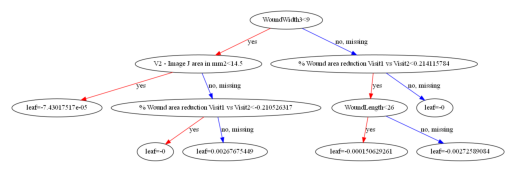

<Figure size 40000x12000 with 0 Axes>

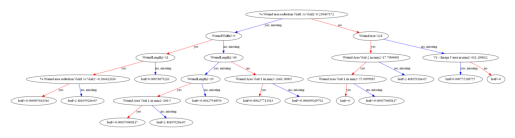

<Figure size 40000x12000 with 0 Axes>

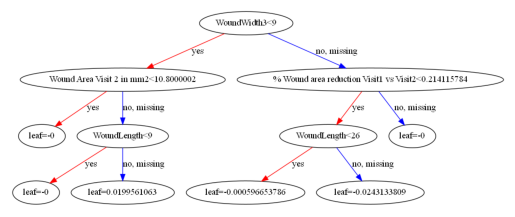

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import re
import matplotlib
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import plot_tree
import graphviz
from xgboost import XGBRegressor
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier
import pickle


Treatment=pd.read_csv("../dissertation/Wound area data v2.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,30)
R_state=14
print("Random_state: ",R_state)
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=R_state,stratify=df_y)

y_train_clf = to_categorical(y_train)
y_test_clf = to_categorical(y_test)

fullinfo=True
fulltree=True



def class1():
    clf=XGBClassifier(tree_method="hist",
                      subsample=0.6,
                      colsample_bynode=0.8,
                      colsample_bylevel=0.7,
                      reg_lambda=0.6,
                      reg_alpha=0.7,
                      max_bin=2056,
                      num_parallel_tree=15,
                      eta=0.03,

    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
        
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------Classifier 1-------------------------------")
    return clf

def class2():
    clf=XGBClassifier(tree_method="hist",
                      max_bin=2056,
                      num_parallel_tree=15,
                      eta=0.03,
                      reg_lambda=0.6,
                      reg_alpha=0.7,
                      objective="reg:pseudohubererror"
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------Classifier 2-------------------------------")
    return clf

def class3():
    clf=XGBClassifier(tree_method="approx",
                  eta=0.02,
                  subsample=0.5,
                 
                   
                   max_bin=2056,
                    reg_alpha=0.8,
                 reg_lambda=0.8,
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(400, 120))
            plot_tree(clf)
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------Classifier 3-------------------------------")
    return clf
    

    
def VoteClass():
    clf1=class1()
    clf2=class2()
    clf3=class3()
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print(classification_report(np.asarray(y_test_clf).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
    accuracy = accuracy_score(np.asarray(y_test_clf).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    
    y_pred = sclf.predict_proba(X_test)
    print(y_pred)
    
    
    
   
VoteClass()